In [4]:
import numpy as np
import pandas as panda
import matplotlib.pyplot as plt
data = panda.read_csv("Train.csv")
df = data.copy()
df.head(100)

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Tata Tiago 1.2 Revotron XZ WO Alloy,Hyderabad,2017,16500,Petrol,Manual,First,23.84 kmpl,1199 CC,84 bhp,5.0,5.00
1,1,Mahindra TUV 300 2015-2019 mHAWK100 T8 AMT,Kochi,2017,47357,Diesel,Automatic,First,18.49 kmpl,1493 CC,100 bhp,7.0,8.37
2,2,Skoda Rapid 2013-2016 1.6 MPI Ambition,Mumbai,2014,35000,Petrol,Manual,First,15.0 kmpl,1598 CC,103.52 bhp,5.0,4.50
3,3,Tata Indica V2 DLS BSII,Jaipur,2007,200000,Diesel,Manual,Second,17.2 kmpl,1396 CC,53.5 bhp,5.0,0.85
4,4,Tata Manza Club Class Quadrajet90 LX,Mumbai,2013,64000,Diesel,Manual,Second,21.02 kmpl,1248 CC,88.76 bhp,5.0,2.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,Mercedes-Benz New C-Class C 220 CDI Elegance AT,Hyderabad,2010,107000,Diesel,Automatic,First,14.84 kmpl,2143 CC,170 bhp,5.0,11.99
96,96,Renault Koleos 2.0 Diesel,Delhi,2013,65000,Diesel,Automatic,Second,13.73 kmpl,1995 CC,148 bhp,5.0,7.50
97,97,Hyundai Elantra CRDi SX AT,Pune,2013,48823,Diesel,Automatic,First,19.5 kmpl,1582 CC,126.24 bhp,5.0,8.50
98,98,Maruti Swift ZXI,Ahmedabad,2015,40000,Petrol,Manual,First,20.4 kmpl,1197 CC,81.80 bhp,5.0,5.90


In [5]:
df.info() 
'''
mileage has 1 empty column
engine has 28 empty columns
power has 28 empty columns
seats has 32 empty columns
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3750 non-null   int64  
 1   Name               3750 non-null   object 
 2   Location           3750 non-null   object 
 3   Year               3750 non-null   int64  
 4   Kilometers_Driven  3750 non-null   int64  
 5   Fuel_Type          3750 non-null   object 
 6   Transmission       3750 non-null   object 
 7   Owner_Type         3750 non-null   object 
 8   Mileage            3749 non-null   object 
 9   Engine             3722 non-null   object 
 10  Power              3722 non-null   object 
 11  Seats              3718 non-null   float64
 12  Price              3750 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 381.0+ KB


'\nmileage has 1 empty column\nengine has 28 empty columns\npower has 28 empty columns\nseats has 32 empty columns\n'

In [6]:
df.describe()

,Unnamed: 0,Year,Kilometers_Driven,Seats,Price
count,3750.000000,3750.000000,3750.000000,3718.000000,3750.000000
mean,1874.500000,2013.313333,58128.811733,5.277838,9.498632
std,1082.676083,3.264250,40343.978048,0.806216,11.207836
min,0.000000,1998.000000,1000.000000,2.000000,0.440000
25%,937.250000,2011.000000,34000.000000,5.000000,3.500000
50%,1874.500000,2014.000000,53000.000000,5.000000,5.665000
75%,2811.750000,2016.000000,73157.750000,5.000000,9.900000
max,3749.000000,2019.000000,775000.000000,10.000000,160.000000


In [7]:
df.isnull().sum()

Unnamed: 0            0
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               1
Engine               28
Power                28
Seats                32
Price                 0
dtype: int64

In [8]:
type(df)
df
df = df.drop(['Unnamed: 0', 'Name'], axis=1)

In [9]:

df['Mileage'] = df['Mileage'].str.replace(' kmpl', '').astype(float)
df['Engine'] = df['Engine'].str.replace(' CC', '').astype(float)
df['Power'] = df['Power'].str.extract('(\d+.\d+)').astype(float)


## replacing null values with median of column
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)
df['Engine'].fillna(df['Engine'].median(), inplace=True)
df['Power'].fillna(df['Power'].median(), inplace=True)
df['Seats'].fillna(df['Seats'].median(), inplace=True)


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12828\1350727933.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Power'] = df['Power'].str.extract('(\d+.\d+)').astype(float)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12828\1350727933.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mileage'].fillna(df['Mileage'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12828\13507279

In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           3750 non-null   object 
 1   Year               3750 non-null   int64  
 2   Kilometers_Driven  3750 non-null   int64  
 3   Fuel_Type          3750 non-null   object 
 4   Transmission       3750 non-null   object 
 5   Owner_Type         3750 non-null   object 
 6   Mileage            3750 non-null   float64
 7   Engine             3750 non-null   float64
 8   Power              3750 non-null   float64
 9   Seats              3750 non-null   float64
 10  Price              3750 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 322.4+ KB


In [11]:
km = df["Kilometers_Driven"].tolist()
mil = df["Mileage"].tolist()
pow = df["Power"].tolist()

yr = df["Year"].tolist()
eng = df["Engine"].tolist()
seat = df["Seats"].tolist()


# print(pow)
pr = df["Price"].tolist()
df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           3750 non-null   object 
 1   Year               3750 non-null   int64  
 2   Kilometers_Driven  3750 non-null   int64  
 3   Fuel_Type          3750 non-null   object 
 4   Transmission       3750 non-null   object 
 5   Owner_Type         3750 non-null   object 
 6   Mileage            3750 non-null   float64
 7   Engine             3750 non-null   float64
 8   Power              3750 non-null   float64
 9   Seats              3750 non-null   float64
 10  Price              3750 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 322.4+ KB


In [12]:
## changing names of columns for better understanding

df.rename(columns={'Mileage': 'Mileage (kmpl)', 'Engine': 'Engine (CC)', 'Power': 'Power (bhp)'})


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage (kmpl),Engine (CC),Power (bhp),Seats,Price
0,Hyderabad,2017,16500,Petrol,Manual,First,23.84,1199.0,103.60,5.0,5.00
1,Kochi,2017,47357,Diesel,Automatic,First,18.49,1493.0,100.00,7.0,8.37
2,Mumbai,2014,35000,Petrol,Manual,First,15.00,1598.0,103.52,5.0,4.50
3,Jaipur,2007,200000,Diesel,Manual,Second,17.20,1396.0,53.50,5.0,0.85
4,Mumbai,2013,64000,Diesel,Manual,Second,21.02,1248.0,88.76,5.0,2.65
...,...,...,...,...,...,...,...,...,...,...,...
3745,Chennai,2009,150000,Diesel,Automatic,First,11.00,2993.0,235.00,5.0,18.75
3746,Delhi,2012,85000,Diesel,Automatic,First,11.79,2179.0,120.00,7.0,6.25
3747,Ahmedabad,2007,55100,Petrol,Manual,First,18.90,998.0,67.10,5.0,1.45
3748,Hyderabad,2014,77500,Diesel,Manual,First,20.45,1461.0,83.80,5.0,6.60


In [13]:
df.shape

(3750, 11)

In [14]:
## checking for unique values

df["Transmission"].unique()

# df["Fuel_Type"].value_counts().to_dict()
# df["Transmission"].value_counts().to_dict()

# df["Location"].value_counts().to_dict()
df["Owner_Type"].unique()
df["Fuel_Type"].unique()
df["Location"].unique()

array(['Hyderabad', 'Kochi', 'Mumbai', 'Jaipur', 'Pune', 'Kolkata',
       'Coimbatore', 'Bangalore', 'Delhi', 'Chennai', 'Ahmedabad'],
      dtype=object)

In [15]:
### encoding non numberical features 

df["Transmission"] = df["Transmission"].map({"Manual": 0 , "Automatic": 1})   ##giving 0 for manual and 1 for automatic
df["Owner_Type"] = df["Owner_Type"].map({"First": 1, "Second": 2, "Third" : 3, "Fourth & Above": 4} )
df["Fuel_Type"] = df["Fuel_Type"].map({"Petrol": 1, "Diesel" : 2, "Electric": 3})
data = panda.get_dummies(df, columns=['Location']).astype(float)


In [16]:
print(data)
data.info()

        Year  Kilometers_Driven  Fuel_Type  Transmission  Owner_Type  Mileage  \
0     2017.0            16500.0        1.0           0.0         1.0    23.84   
1     2017.0            47357.0        2.0           1.0         1.0    18.49   
2     2014.0            35000.0        1.0           0.0         1.0    15.00   
3     2007.0           200000.0        2.0           0.0         2.0    17.20   
4     2013.0            64000.0        2.0           0.0         2.0    21.02   
...      ...                ...        ...           ...         ...      ...   
3745  2009.0           150000.0        2.0           1.0         1.0    11.00   
3746  2012.0            85000.0        2.0           1.0         1.0    11.79   
3747  2007.0            55100.0        1.0           0.0         1.0    18.90   
3748  2014.0            77500.0        2.0           0.0         1.0    20.45   
3749  2012.0            40000.0        1.0           0.0         1.0    18.90   

      Engine   Power  Seats

In [17]:
print(data)


        Year  Kilometers_Driven  Fuel_Type  Transmission  Owner_Type  Mileage  \
0     2017.0            16500.0        1.0           0.0         1.0    23.84   
1     2017.0            47357.0        2.0           1.0         1.0    18.49   
2     2014.0            35000.0        1.0           0.0         1.0    15.00   
3     2007.0           200000.0        2.0           0.0         2.0    17.20   
4     2013.0            64000.0        2.0           0.0         2.0    21.02   
...      ...                ...        ...           ...         ...      ...   
3745  2009.0           150000.0        2.0           1.0         1.0    11.00   
3746  2012.0            85000.0        2.0           1.0         1.0    11.79   
3747  2007.0            55100.0        1.0           0.0         1.0    18.90   
3748  2014.0            77500.0        2.0           0.0         1.0    20.45   
3749  2012.0            40000.0        1.0           0.0         1.0    18.90   

      Engine   Power  Seats

In [18]:
## checking if any featues are correlated or not 

data.corr()
#engine and power has high correlative constant -- 0.864727	
# power and price has high correlative constant -- 0.761909	
#engine and price has high correlative constant -- 0.649705
#mileage and engine has high correlative constant -- (-0.631421)
# power and transmission 0.625432

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,...,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune
Year,1.000000,-0.426688,0.123080,0.108084,-0.391368,0.328636,-0.052797,-0.006043,0.021399,0.311836,...,-0.046385,-0.136768,0.223987,-0.011408,-0.093105,-0.097725,0.219332,-0.013310,0.011179,-0.092939
Kilometers_Driven,-0.426688,1.000000,0.212958,-0.101796,0.184114,-0.140579,0.144822,0.013267,0.184737,-0.161540,...,0.005785,0.155362,-0.099633,0.006231,0.123285,0.110366,-0.114393,-0.104028,-0.129184,0.086471
Fuel_Type,0.123080,0.212958,1.000000,0.144682,-0.043430,0.130801,0.426574,0.295736,0.307223,0.320814,...,0.042384,0.026045,0.011578,0.024626,0.106318,0.014273,-0.052469,-0.019897,-0.097928,-0.057025
Transmission,0.108084,-0.101796,0.144682,1.000000,0.005960,-0.323734,0.498195,0.625432,-0.079759,0.587183,...,0.075037,-0.035784,0.097202,0.000810,-0.019058,-0.104797,0.019322,-0.090415,0.078597,-0.038485
Owner_Type,-0.391368,0.184114,-0.043430,0.005960,1.000000,-0.155755,0.046620,0.033842,0.003942,-0.101788,...,0.136204,0.160843,-0.084782,-0.022694,-0.084708,0.069160,-0.104447,-0.104278,-0.003823,0.099828
Mileage,0.328636,-0.140579,0.130801,-0.323734,-0.155755,1.000000,-0.571010,-0.481825,-0.277417,-0.296908,...,-0.084305,0.007846,-0.025704,-0.021639,0.018532,0.057445,0.029415,0.074189,-0.065481,-0.009073
Engine,-0.052797,0.144822,0.426574,0.498195,0.046620,-0.571010,1.000000,0.840751,0.384655,0.648792,...,0.086765,-0.013976,0.060450,0.041867,0.009699,-0.091202,-0.012007,-0.060714,0.041891,-0.061995
Power,-0.006043,0.013267,0.295736,0.625432,0.033842,-0.481825,0.840751,1.000000,0.074844,0.747989,...,0.096350,-0.028838,0.080488,0.018996,-0.028363,-0.096973,0.005801,-0.050450,0.070937,-0.068694
Seats,0.021399,0.184737,0.307223,-0.079759,0.003942,-0.277417,0.384655,0.074844,1.000000,0.053150,...,0.002115,-0.006095,0.007552,0.059663,0.042970,-0.017830,-0.017412,-0.045212,-0.004188,-0.025811
Price,0.311836,-0.161540,0.320814,0.587183,-0.101788,-0.296908,0.648792,0.747989,0.053150,1.000000,...,0.091288,-0.058011,0.183106,-0.023570,0.011948,-0.105221,0.063392,-0.092894,0.010867,-0.087945


In [19]:
data

,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,...,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,Location_Hyderabad,Location_Jaipur,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune
0,2017.0,16500.0,1.0,0.0,1.0,23.84,1199.0,103.60,5.0,5.00,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2017.0,47357.0,2.0,1.0,1.0,18.49,1493.0,100.00,7.0,8.37,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2014.0,35000.0,1.0,0.0,1.0,15.00,1598.0,103.52,5.0,4.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2007.0,200000.0,2.0,0.0,2.0,17.20,1396.0,53.50,5.0,0.85,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2013.0,64000.0,2.0,0.0,2.0,21.02,1248.0,88.76,5.0,2.65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,2009.0,150000.0,2.0,1.0,1.0,11.00,2993.0,235.00,5.0,18.75,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3746,2012.0,85000.0,2.0,1.0,1.0,11.79,2179.0,120.00,7.0,6.25,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3747,2007.0,55100.0,1.0,0.0,1.0,18.90,998.0,67.10,5.0,1.45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3748,2014.0,77500.0,2.0,0.0,1.0,20.45,1461.0,83.80,5.0,6.60,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


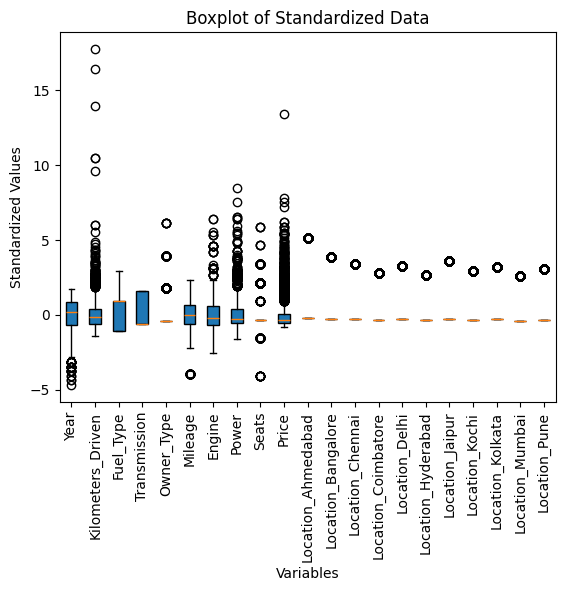

In [20]:

means = data.mean()
std_devs = data.std()

# # Apply standardization, this is also called z score normalization -- transforms the data to have a mean of 0 and a standard deviation of 1 
standardized_data = (data - means) / std_devs
plt.boxplot(standardized_data.values, vert=True, patch_artist=True)
plt.xticks(range(1, standardized_data.shape[1] + 1), standardized_data.columns, rotation=90)
plt.xlabel("Variables")
plt.ylabel("Standardized Values")
plt.title("Boxplot of Standardized Data")
plt.show()


In [21]:
# Extract columns from standardized_data into individual lists
yr = standardized_data["Year"].tolist()
km = standardized_data["Kilometers_Driven"].tolist()
ft = standardized_data["Fuel_Type"].tolist()
tr = standardized_data["Transmission"].tolist()
ot = standardized_data["Owner_Type"].tolist()
mil = standardized_data["Mileage"].tolist()
eng = standardized_data["Engine"].tolist()
pow = standardized_data["Power"].tolist()
seat = standardized_data["Seats"].tolist()

l_ahmedabad = standardized_data["Location_Ahmedabad"].tolist()
l_bangalore = standardized_data["Location_Bangalore"].tolist()
l_chennai = standardized_data["Location_Chennai"].tolist()
l_coimbatore = standardized_data["Location_Coimbatore"].tolist()
l_delhi = standardized_data["Location_Delhi"].tolist()
l_hyderabad = standardized_data["Location_Hyderabad"].tolist()
l_jaipur = standardized_data["Location_Jaipur"].tolist()
l_kochi = standardized_data["Location_Kochi"].tolist()
l_kolkata = standardized_data["Location_Kolkata"].tolist()
l_mumbai = standardized_data["Location_Mumbai"].tolist()
l_pune = standardized_data["Location_Pune"].tolist()

list = [yr, km, ft, tr, ot, mil, eng, pow, seat, l_ahmedabad, l_bangalore, l_chennai, l_coimbatore, l_delhi, l_hyderabad, l_jaipur, l_kochi, l_kolkata, l_mumbai, l_pune]
list_names = ["Year","Kilometers_Driven","Fuel_Type", "Transmission", "Owner_Type","Mileage", "Engine", "Power", "Seats", "Location_Ahmedabad", "Location_Bangalore", "Location_Chennai", "Location_Coimbatore", "Location_Delhi","Location_Hyderabad", "Location_Jaipur", "Location_Kochi" , "Location_Kolkata", "Location_Mumbai","Location_Pune"]
pr = standardized_data["Price"].tolist()

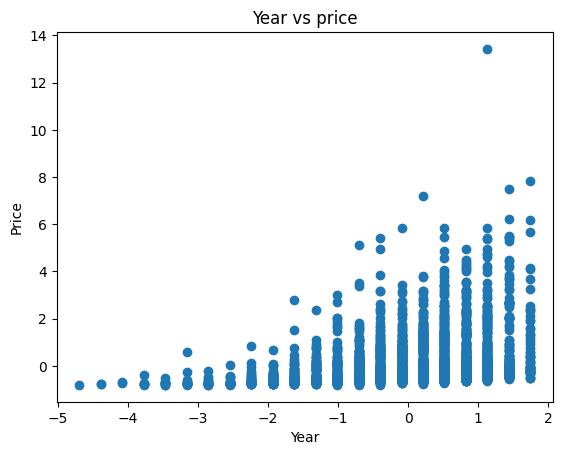

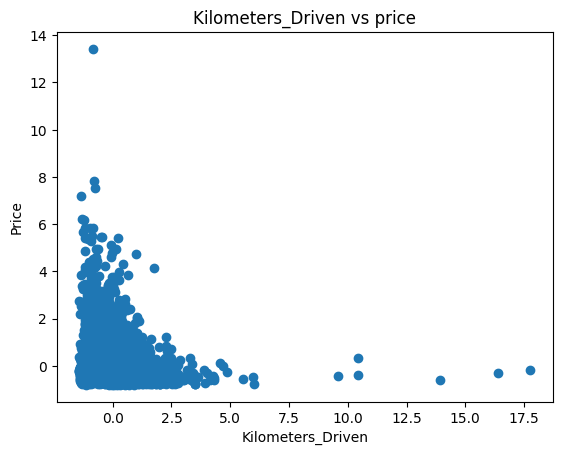

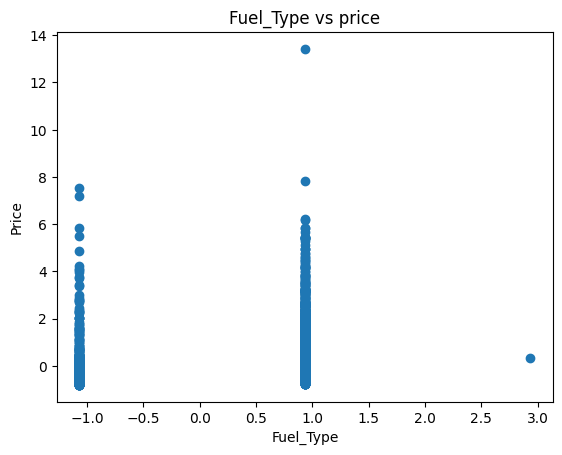

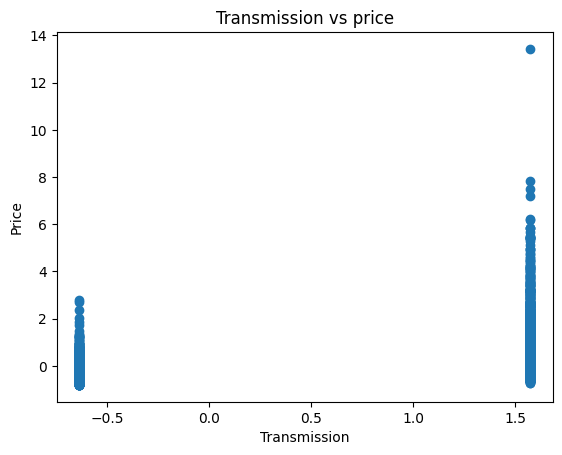

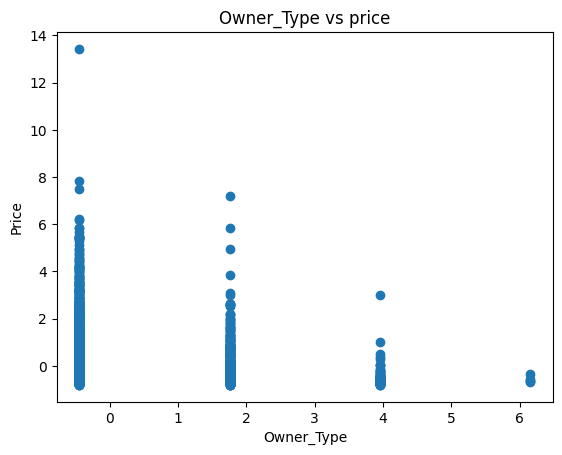

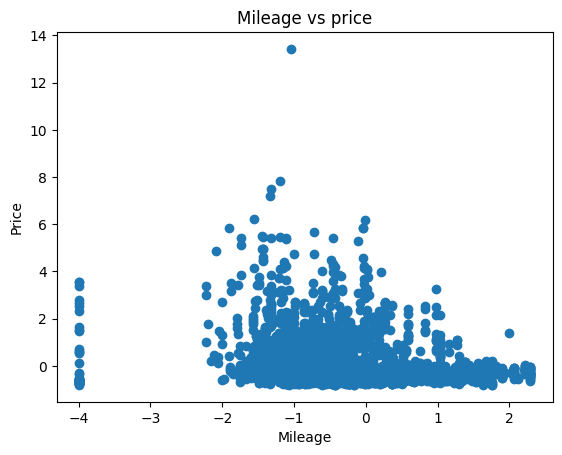

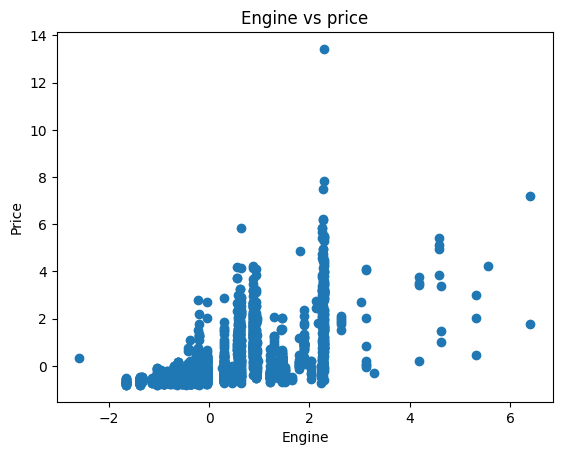

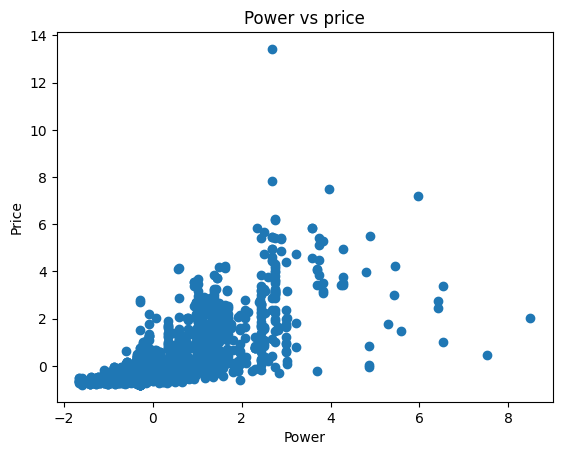

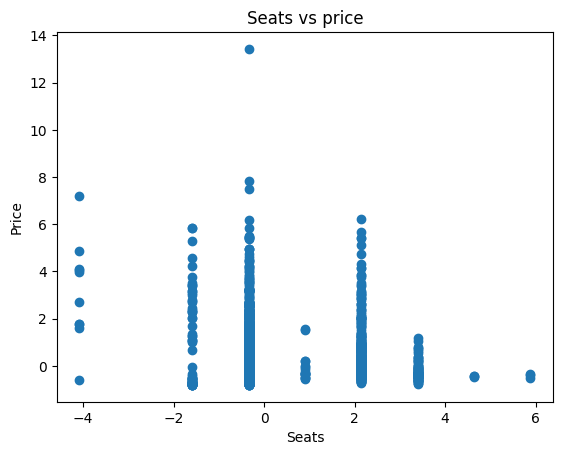

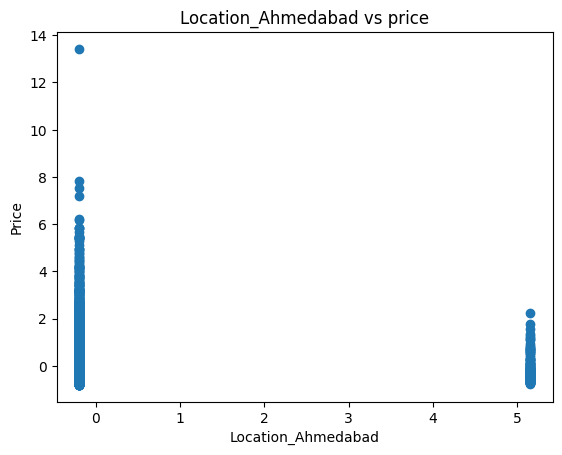

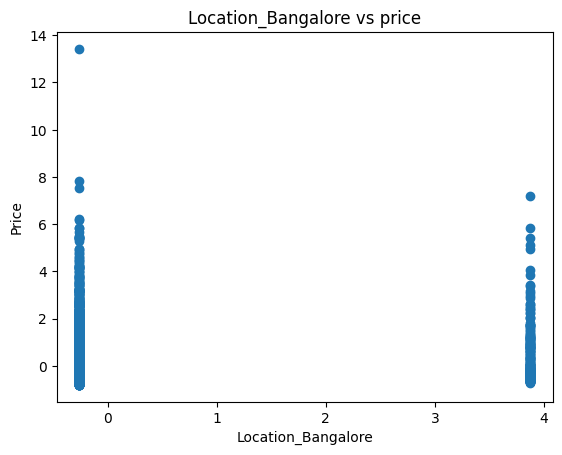

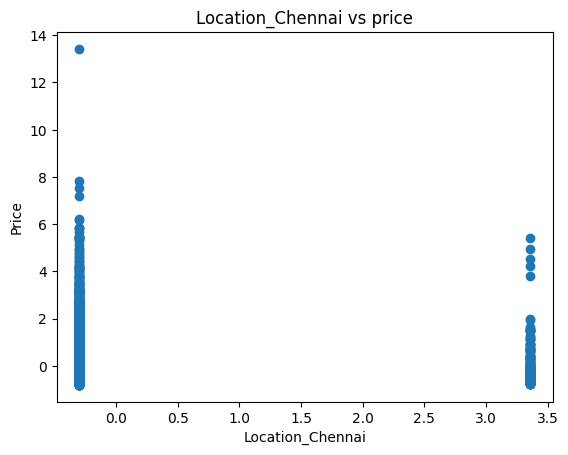

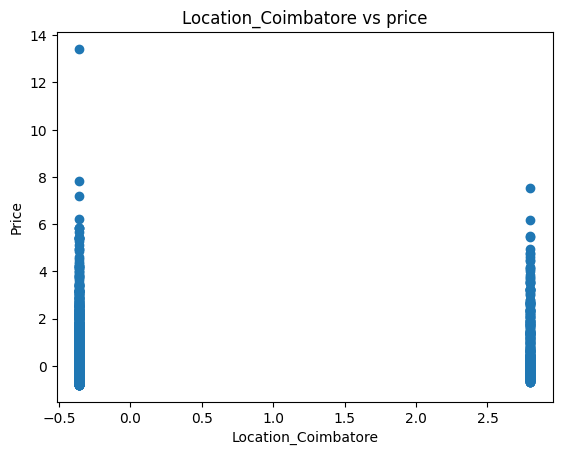

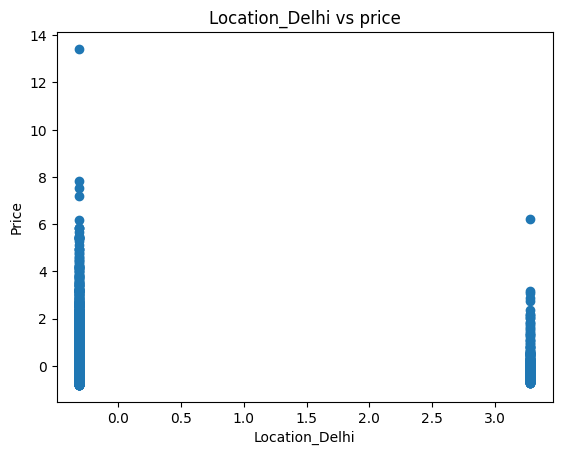

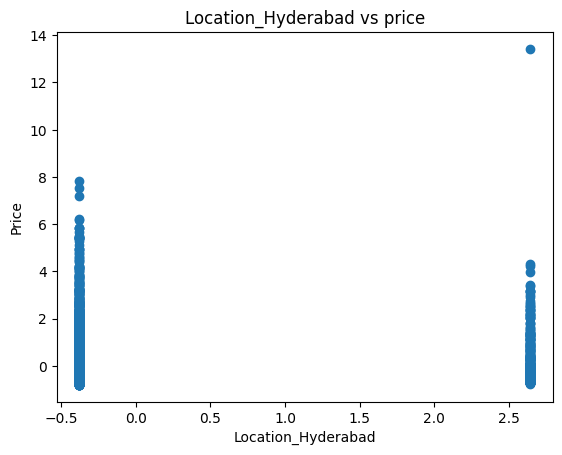

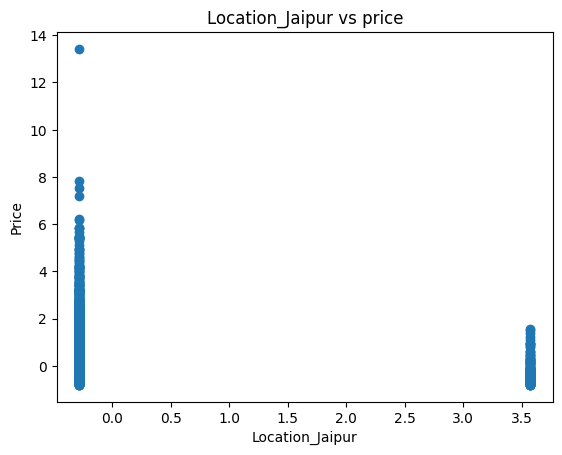

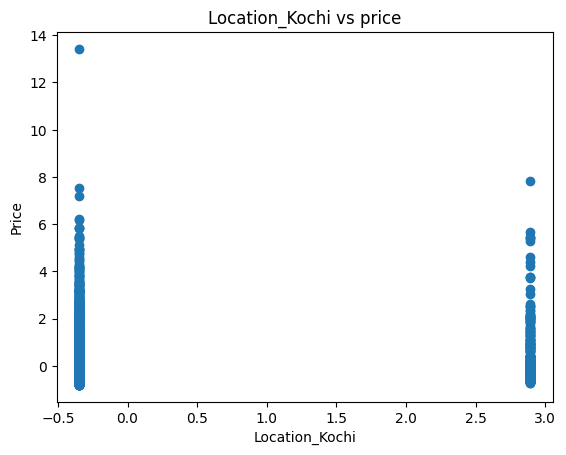

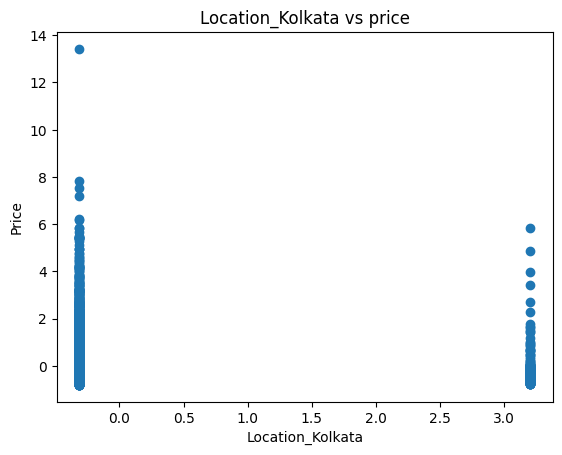

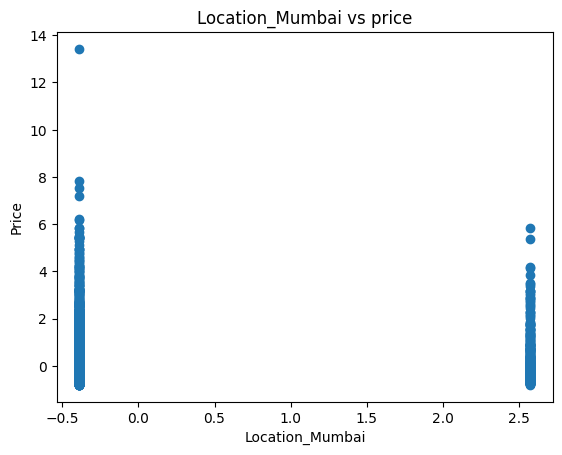

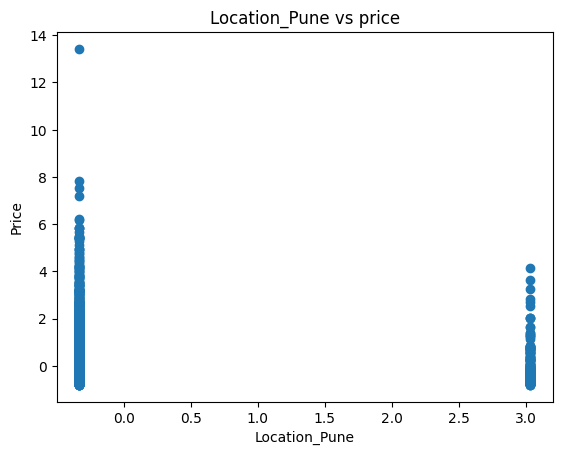

In [22]:

for i in range(len(list)):
  x = list[i]
  x_name = list_names[i]
  plt.scatter(x, pr)
  plt.xlabel(x_name)
  plt.ylabel("Price")
  plt.title(f"{x_name} vs price")
  plt.savefig(f"{x_name}_Price.jpg")
  plt.show()
 


In [23]:


X = standardized_data.drop(columns = ["Price"])
Y = standardized_data["Price"]
intercept = np.ones((X.shape[0], 1))
X = np.hstack((intercept, X))


In [24]:
## with normal equation y = b0 + x1b1 + x2b2 + ......xpbp
XtX = np.dot(X.T, X)
XtX_inv = np.linalg.inv(XtX) ##(XtX)-1
XtY = np.dot(X.T,Y)  ##(XtY)
beta = np.dot(XtX_inv, XtY)
beta

array([-4.86712677e-15,  2.83604927e-01, -8.95666047e-02,  1.06688919e-01,
        1.18693227e-01, -1.12535342e-02, -8.26938403e-02,  1.24808093e-01,
        5.04784374e-01, -7.16895969e-02,  7.63719438e-03,  5.03291145e-02,
        4.17149307e-02,  6.59091105e-02,  5.09587097e-03,  9.03770240e-02,
        4.12529369e-02,  2.87832097e-02, -1.35893024e-02, -8.05775957e-03,
        3.34961166e-02])

In [25]:
Y_pred = np.dot(X,beta)
Y_pred


array([ 0.07584859,  0.2480311 , -0.27901878, ..., -1.4252252 ,
       -0.18685974, -1.04590381], shape=(3750,))

In [26]:
test = panda.read_csv("Test.csv")
test.isnull().sum()

Unnamed: 0           0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              1
Engine               6
Power                6
Seats                7
Price                0
dtype: int64

In [27]:
test.dropna()
test.isnull().sum()
# test.info()

Unnamed: 0           0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              1
Engine               6
Power                6
Seats                7
Price                0
dtype: int64

In [28]:
print(test)

test["Mileage"] = test["Mileage"].str.replace(" kmpl", "").astype(float)




      Unnamed: 0                           Name    Location  Year  \
0              0         Maruti Swift Dzire VDI   Hyderabad  2013   
1              1          Hyundai i10 Sportz AT       Delhi  2012   
2              2  Hyundai Elite i20 Sportz Plus       Kochi  2017   
3              3                  Volvo XC60 D5        Pune  2011   
4              4          Hyundai i10 Magna 1.2       Delhi  2013   
...          ...                            ...         ...   ...   
1245        1245     Hyundai Elantra CRDi SX AT       Delhi  2013   
1246        1246           Hyundai Getz GLS ABS        Pune  2005   
1247        1247         Volkswagen Polo GT TSI  Coimbatore  2017   
1248        1248       Hyundai Verna SX CRDi AT        Pune  2012   
1249        1249        Maruti Baleno Alpha CVT       Kochi  2019   

      Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage  \
0                 84175    Diesel       Manual      First   23.4 kmpl   
1                 62282  

In [29]:
test["Engine"] = test["Engine"].str.replace(" CC", "").astype(float)


In [30]:
test['Power'] = test['Power'].str.extract('(\d+.\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12828\3917703834.py:1: SyntaxWarning: invalid escape sequence '\d'
  test['Power'] = test['Power'].str.extract('(\d+.\d+)').astype(float)


In [31]:
print(test)
test.info()
test = test.dropna()
test.info()

      Unnamed: 0                           Name    Location  Year  \
0              0         Maruti Swift Dzire VDI   Hyderabad  2013   
1              1          Hyundai i10 Sportz AT       Delhi  2012   
2              2  Hyundai Elite i20 Sportz Plus       Kochi  2017   
3              3                  Volvo XC60 D5        Pune  2011   
4              4          Hyundai i10 Magna 1.2       Delhi  2013   
...          ...                            ...         ...   ...   
1245        1245     Hyundai Elantra CRDi SX AT       Delhi  2013   
1246        1246           Hyundai Getz GLS ABS        Pune  2005   
1247        1247         Volkswagen Polo GT TSI  Coimbatore  2017   
1248        1248       Hyundai Verna SX CRDi AT        Pune  2012   
1249        1249        Maruti Baleno Alpha CVT       Kochi  2019   

      Kilometers_Driven Fuel_Type Transmission Owner_Type  Mileage  Engine  \
0                 84175    Diesel       Manual      First    23.40  1248.0   
1              

In [32]:
test

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
1,1,Hyundai i10 Sportz AT,Delhi,2012,62282,Petrol,Automatic,First,16.95,1197.0,78.90,5.0,2.90
2,2,Hyundai Elite i20 Sportz Plus,Kochi,2017,37460,Petrol,Manual,First,18.60,1197.0,81.86,5.0,6.28
3,3,Volvo XC60 D5,Pune,2011,106976,Diesel,Automatic,First,13.50,2400.0,215.00,5.0,13.80
4,4,Hyundai i10 Magna 1.2,Delhi,2013,60000,Petrol,Manual,First,20.36,1197.0,78.90,5.0,2.75
5,5,Audi A6 2.7 TDI,Kolkata,2010,35000,Diesel,Automatic,First,12.40,2698.0,179.50,5.0,11.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,1243,Chevrolet Beat LT,Kochi,2012,83381,Petrol,Manual,First,18.60,1199.0,79.40,5.0,2.21
1245,1245,Hyundai Elantra CRDi SX AT,Delhi,2013,71000,Diesel,Automatic,First,22.70,1582.0,126.20,5.0,6.80
1247,1247,Volkswagen Polo GT TSI,Coimbatore,2017,50534,Petrol,Automatic,First,17.21,1197.0,103.50,5.0,8.27
1248,1248,Hyundai Verna SX CRDi AT,Pune,2012,83000,Diesel,Automatic,First,19.08,1582.0,126.32,5.0,6.00


In [33]:
test["Fuel_Type"] = test["Fuel_Type"].map({"Petrol": 1 , "Diesel": 2, "Electric": 3})


In [34]:
test["Owner_Type"] = test["Owner_Type"].map({"First": 1, "Second": 2, "Third": 3, "Fourth & Above": 4})


In [35]:
test["Transmission"] = test["Transmission"].map({"Manual": 0, "Automatic": 1})


In [36]:
test = test.drop(["Unnamed: 0", "Name"],axis = 1)

In [37]:
test = panda.get_dummies(test, columns = ["Location"]).astype(float)


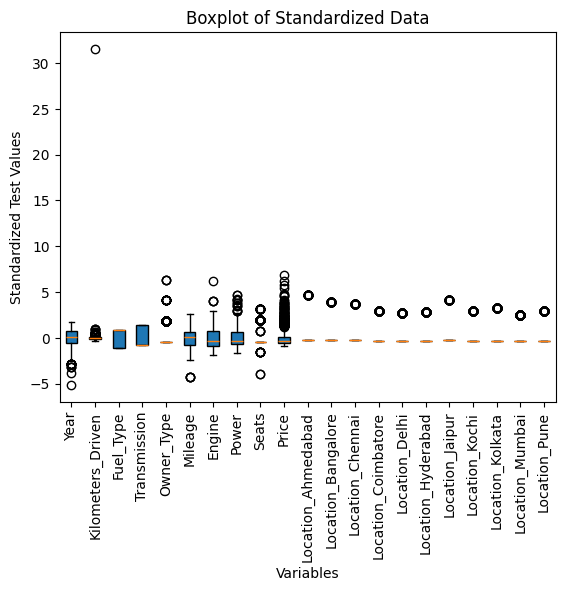

In [38]:
means = test.mean()
std_devs = test.std()

#applying standardization
standardized_test = (test - means) / std_devs
plt.boxplot(standardized_test.values,patch_artist=True)
plt.xticks(range(1, standardized_test.shape[1] + 1), standardized_test.columns, rotation=90)
plt.xlabel("Variables")
plt.ylabel("Standardized Test Values")
plt.title("Boxplot of Standardized Data")
plt.savefig("Box plot of test values")
plt.show()

In [39]:
X_test = standardized_test.drop(columns = ["Price"])
Y_test = standardized_test["Price"]
intercept = np.ones((X_test.shape[0], 1))
X_test = np.hstack((intercept, X_test))


In [40]:
Y_predic = np.dot(X_test, beta)

In [41]:
mse = np.sum((Y_test - Y_predic) ** 2)/len(Y_test)
print("Mean Squared Error:", mse)                      
Y_mean = np.mean(Y_test)
mse_mean = np.mean((Y_test - Y_mean) ** 2)
r_squared = 1 - (mse / mse_mean)

print("R-squared:", r_squared)


Mean Squared Error: 0.32355657485516864
R-squared: 0.6761271430579738


In [42]:
## usuing gradient descent optimization
X_gd = standardized_data.drop(columns = ["Price"])
Y_gd = standardized_data["Price"]
intercept = np.ones((X_gd.shape[0], 1))
X_gd = np.hstack((intercept, X_gd)) 

m,n = X_gd.shape
## contains slope and intercept ----- X(m, n+1) * beta(n+1, 1)
beta = np.zeros((n,1))   ## initializing beta to zero
Y_gd = Y_gd.values.reshape(-1,1)
def cost(X,Y,beta,m):
    hx = np.dot(X,beta)
    cost = (1/(2*m))* (np.dot(((hx-Y).T), (hx - Y)))
    return cost
    
def gradient_descent(learning_rate,beta,X,Y,m):
    hx = np.dot(X,beta)
    beta -= (learning_rate)*(1/m)*(np.dot(X.T,(hx-Y)))
    return beta
hx = np.dot(X_gd,beta)


learning_rate = .07
iterations = 1000

cost_history = []
for i in range(iterations):
    beta = gradient_descent(learning_rate,beta,X_gd,Y_gd,m)
    cosT = cost(X_gd,Y_gd,beta,m)
    cost_history.append(cosT)
    if i % 50 == 0:
        # print(beta)
        print(cosT)
plt.plot(mse_history)
plt.show()

[[0.39021226]]
[[0.15239049]]
[[0.15097734]]
[[0.15062663]]
[[0.15047321]]
[[0.15039523]]
[[0.15035451]]
[[0.15033317]]
[[0.15032197]]
[[0.15031609]]
[[0.15031301]]
[[0.15031139]]
[[0.15031054]]
[[0.1503101]]
[[0.15030986]]
[[0.15030974]]
[[0.15030967]]
[[0.15030964]]
[[0.15030962]]
[[0.15030961]]


NameError: name 'mse_history' is not defined

In [ ]:
Y_test_gd = standardized_test["Price"]
X_test_gd = standardized_test.drop(columns = ["Price"])
intercept = np.ones((X_test_gd.shape[0], 1))
X_test_gd = np.hstack((intercept,X_test_gd))
Y_test_gd = Y_test_gd.values.reshape(-1,1)
def mse(Y_test_gd,Y_pred):
    return np.mean((Y_test_gd-Y_pred)**2)
def Rsq(Y_test_gd,Y_pred,mse):
    Y_mean_gd = np.mean(Y_test_gd)
    mse_mean = np.mean((Y_test_gd - Y_mean_gd) ** 2)
    return 1-(mse/mse_mean)
# print(beta.shape)
# X_test_gd.shape
# Y_pred.shape
# # Y_test_gd.shape



In [ ]:
Y_pred = np.dot(X_test_gd,beta)
MSE = mse(Y_test_gd, Y_pred)
print("Mean Squared Error:", MSE)
Rsquared = Rsq(Y_test_gd,Y_pred,MSE)
print("R-squared:", Rsquared)

